# LLM Reverse Mode Implementation

## Tokenizer

In [5]:
import torch
from torch import nn
from torch.nn import functional as F
import random
import math
import re
import pickle
import matplotlib.pyplot as plt

pad_token = "[PAD]"
eos_token = "[EOS]"

class character_level_tokenizer:
    def __init__(self):
        self.vocab = [str(x) for x in range(10)] + ["+", "-", "=", "c", "b"] + [pad_token, eos_token]
        self.token_to_id = {v: k for k, v in enumerate(self.vocab)}
        self.id_to_token = {k: v for k, v in enumerate(self.vocab)}
        self.ntokens = len(self.vocab)
        self.pattern = f"[^{re.escape(''.join(self.vocab))}]"

    def clean(self, text):
        out = re.sub(self.pattern, "", text)
        return out

    def pre_tokenization(self, text):
        return [c for c in text]

    def encode(self, text):
        text_list = self.pre_tokenization(self.clean(text))        
        return [self.token_to_id[c] for c in text_list]

    def decode(self, token_list):
        return "".join([self.id_to_token[i] for i in token_list])

In [6]:
tokenizer = character_level_tokenizer()
print(f"Vocabulary ({tokenizer.ntokens} tokens):", tokenizer.vocab)
sample_eq = "123+45="
print(f"Tokenized '{sample_eq}':", tokenizer.encode(sample_eq))

Vocabulary (17 tokens): ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '+', '-', '=', 'c', 'b', '[PAD]', '[EOS]']
Tokenized '123+45=': [1, 2, 3, 10, 4, 5, 12]


## Dataset Generation and Batching

In [7]:
def sample_datapoint(number_digits=3, force_negative=False):
    """
    Returns (prompt, ans_forward, ans_reverse)
    """
    a_list = [random.randint(0, 9) for _ in range(number_digits)]
    a_int = int("".join([str(x) for x in a_list]))
    
    b_list = [random.randint(0, 9) for _ in range(number_digits)]
    b_int = int("".join([str(x) for x in b_list]))

    if force_negative:
        op = "-"
        if a_int >= b_int:
            a_int, b_int = b_int, a_int
            if a_int == b_int:
                b_int += 1
    else:
        op = random.choice(["+", "-"])
        if op == "-":
            if a_int < b_int:
                a_int, b_int = b_int, a_int

    if op == "+":
        sum_int = a_int + b_int
    else:
        sum_int = a_int - b_int

    prompt = f"{a_int}{op}{b_int}="
    
    ans_forward = str(sum_int)
    
    out_rev = ""
    if op == "+":
        a_str = str(a_int)
        b_str = str(b_int)
        max_len = max(len(a_str), len(b_str))
        a_str = a_str.zfill(max_len)
        b_str = b_str.zfill(max_len)
        carry = 0
        for i in range(max_len - 1, -1, -1):
            d1 = int(a_str[i])
            d2 = int(b_str[i])
            s = d1 + d2 + carry
            digit = s % 10
            carry = s // 10
            out_rev += str(digit)
            if carry > 0:
                out_rev += "c1"
        if carry > 0:
            out_rev += str(carry)
    else:
        a_tmp, b_tmp = a_int, b_int
        if a_tmp < b_tmp:
            out_rev += "-"
            a_tmp, b_tmp = b_tmp, a_tmp
            
        a_str = str(a_tmp)
        b_str = str(b_tmp)
        max_len = max(len(a_str), len(b_str))
        a_str = a_str.zfill(max_len)
        b_str = b_str.zfill(max_len)
        borrow = 0
        
        for i in range(max_len - 1, -1, -1):
            d1 = int(a_str[i])
            d2 = int(b_str[i])
            s = d1 - d2 - borrow
            if s < 0:
                s += 10
                borrow = 1
                b_token = "b1"
            else:
                borrow = 0
                b_token = ""
            out_rev += str(s) + b_token
            
    # Strip trailing zeros (which are leading zeros in normal representation)
    if out_rev == "0" or out_rev == "-0":
        out_rev = "0"
    else:
        has_minus = False
        if out_rev.startswith("-"):
            has_minus = True
            out_rev = out_rev[1:]
        while len(out_rev) > 1 and out_rev.endswith("0"):
            out_rev = out_rev[:-1]
        if has_minus and out_rev != "0":
            out_rev = "-" + out_rev
            
    ans_reverse = out_rev
    return (prompt, ans_forward, ans_reverse)

def pad(token_list, tokenizer, type_list="prompts"):
    assert type_list in ['prompts', 'answers']
    max_length = max([len(x) for x in token_list])
    out = []
    for x in token_list:
        if type_list == "prompts":
            out.append([tokenizer.token_to_id[pad_token]] * (max_length - len(x)) + x)
        if type_list == "answers":
            out.append(x + [tokenizer.token_to_id[eos_token]] + [tokenizer.token_to_id[pad_token]] * (max_length - len(x)))
    return out, max_length

In [8]:
with open("assets/dataset.pkl", "rb") as f:
    dataset = pickle.load(f)
    
data_train = dataset["train"]
data_val = dataset["val"]
data_test = dataset["test"]

print(f"Dataset Loaded. Train: {len(data_train)}, Val: {len(data_val)}, Test: {len(data_test)}")
print("Sample datapoint from train:", data_train[0])

Dataset Loaded. Train: 100000, Val: 20000, Test: 20000
Sample datapoint from train: ('562-829=', '-267', '-76b12')


## Positional Encoding

In [9]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp((torch.arange(0, d_model, 2).float() / d_model) * (-math.log(1e4)))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0)]
        return self.dropout(x)

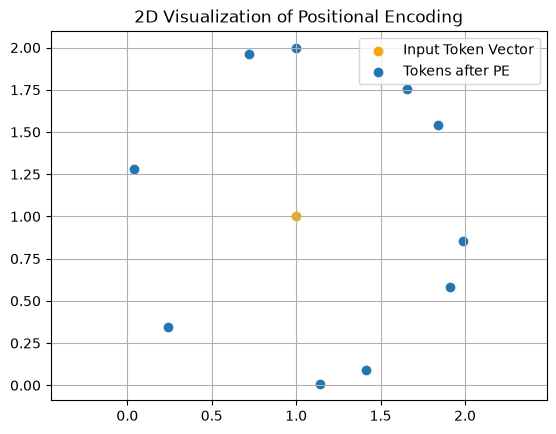

In [10]:
pe_module = PositionalEncoding(d_model=2, dropout=0)
dummy_seq = torch.ones((10, 1, 2))
encoded_seq = pe_module(dummy_seq)

plt.scatter(1, 1, c='orange', label='Input Token Vector')
plt.scatter(encoded_seq[:, 0, 0], encoded_seq[:, 0, 1], label='Tokens after PE')
plt.title("2D Visualization of Positional Encoding")
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

## Transformer Model Architecture

In [11]:
class CustomEncoderLayer(nn.TransformerEncoderLayer):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.attn_weights = None

    def forward(self, src, src_mask=None, src_key_padding_mask=None, is_causal=False, **kwargs):
        src2, attn_weights = self.self_attn(
            src, src, src,
            attn_mask=src_mask,
            key_padding_mask=src_key_padding_mask,
            need_weights=True,
            average_attn_weights=True,
            is_causal=is_causal
        )
        self.attn_weights = attn_weights
        src = src + self.dropout1(src2)
        src = self.norm1(src)
        src2 = self.linear2(self.dropout(self.activation(self.linear1(src))))
        src = src + self.dropout2(src2)
        src = self.norm2(src)
        return src

class TransformerModel(nn.Module):
    def __init__(self, ntoken, ninp, nhead, nhid, nlayers, dropout=0.5):
        super().__init__()
        self.input_emb = nn.Embedding(ntoken, ninp)
        self.pos_encoder = PositionalEncoding(ninp, dropout)
        encoder_layers = CustomEncoderLayer(ninp, nhead, nhid, 0.1)
        self.encoder = nn.TransformerEncoder(encoder_layers, nlayers)
        self.decoder = nn.Linear(ninp, ntoken)
        self.ninp = ninp
        self.init_weights()

    def init_weights(self):
        initrange = 0.1
        nn.init.uniform_(self.input_emb.weight, -initrange, initrange)
        nn.init.zeros_(self.decoder.bias)
        nn.init.uniform_(self.decoder.weight, -initrange, initrange)

    def _generate_square_subsequent_mask(self, sz):
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask

    def forward(self, src):        
        mask = self._generate_square_subsequent_mask(len(src)).to(src.device)
        src = self.input_emb(src) * math.sqrt(self.ninp)
        src = self.pos_encoder(src)
        output_enc = self.encoder(src, mask=mask, is_causal=True) 
        output_dec = self.decoder(output_enc)
        attention_maps = [layer.attn_weights for layer in self.encoder.layers]
        return F.log_softmax(output_dec, dim=-1), output_enc, attention_maps

def generate(model, prompts, new_tokens=5, device='cuda'):
    input_tensor = prompts.to(device)
    for _ in range(new_tokens):
        output, _, _ = model(input_tensor)
        last_output = output[-1, :, :]
        token = torch.argmax(last_output, -1).view((1, -1))
        input_tensor = torch.cat((input_tensor, token), 0)
    return input_tensor

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TransformerModel(ntoken=tokenizer.ntokens, ninp=128, nhead=16, nhid=64, nlayers=6).to(device)
Nparams = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {Nparams}')

/tmp/ipykernel_30447/2641071377.py:29: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = nn.TransformerEncoder(encoder_layers, nlayers)


Total parameters: 503185


## Training Loop & Learning Curve

Starting Training Loop...
Epoch 1/30, Loss: 0.9696 | Val Seq Acc: 0.0730 | Train Seq Acc: 0.0810
Epoch 2/30, Loss: 0.6135 | Val Seq Acc: 0.3600 | Train Seq Acc: 0.3700
Epoch 3/30, Loss: 0.3988 | Val Seq Acc: 0.6480 | Train Seq Acc: 0.6730
Epoch 4/30, Loss: 0.2740 | Val Seq Acc: 0.8350 | Train Seq Acc: 0.8750
Epoch 5/30, Loss: 0.1992 | Val Seq Acc: 0.9400 | Train Seq Acc: 0.9610
Epoch 6/30, Loss: 0.1582 | Val Seq Acc: 0.9760 | Train Seq Acc: 0.9820
Epoch 7/30, Loss: 0.1243 | Val Seq Acc: 0.9910 | Train Seq Acc: 0.9940
Epoch 8/30, Loss: 0.1055 | Val Seq Acc: 0.9790 | Train Seq Acc: 0.9870
Epoch 9/30, Loss: 0.0945 | Val Seq Acc: 0.9910 | Train Seq Acc: 0.9880
Epoch 10/30, Loss: 0.0793 | Val Seq Acc: 0.9940 | Train Seq Acc: 0.9960
Epoch 11/30, Loss: 0.0680 | Val Seq Acc: 0.9890 | Train Seq Acc: 0.9870
Epoch 12/30, Loss: 0.0739 | Val Seq Acc: 0.9930 | Train Seq Acc: 0.9950
Epoch 13/30, Loss: 0.0627 | Val Seq Acc: 0.9960 | Train Seq Acc: 0.9950
Epoch 14/30, Loss: 0.0549 | Val Seq Acc: 0.9980

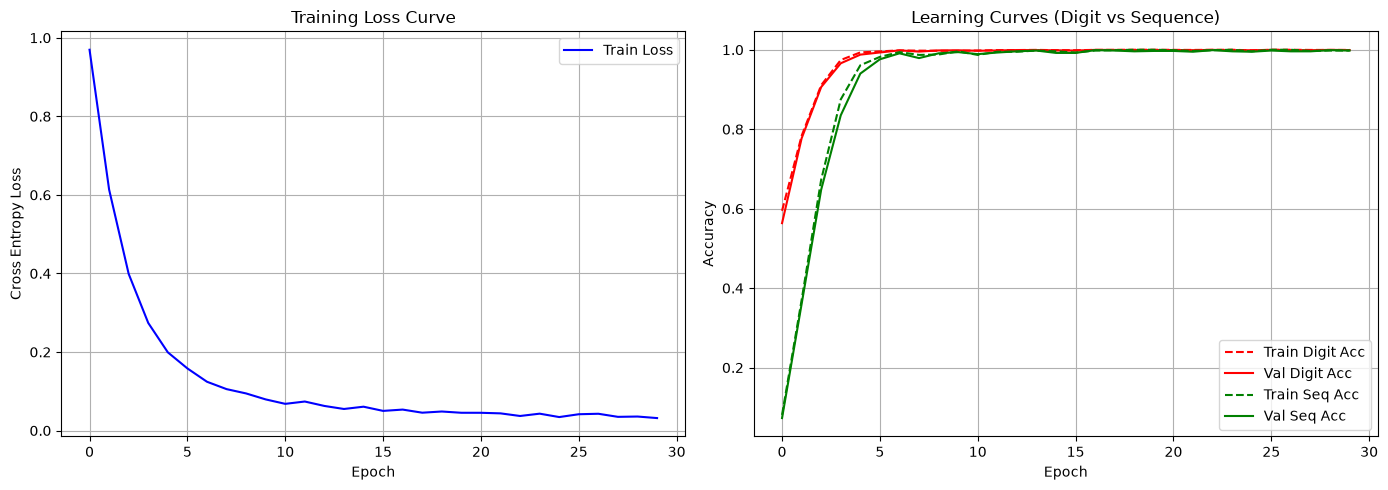

Model saved to assets/reverse_model.pth


In [13]:
def get_batch_lm(data, i, batch_size, tokenizer):
    batch = data[i:i+batch_size]
    prompts = [tokenizer.encode(p) for p, _, a_rev in batch]
    padded_prompts, length_prompts = pad(prompts, tokenizer, "prompts")
    answers = [tokenizer.encode(a_rev) + [tokenizer.token_to_id['[EOS]']] for p, _, a_rev in batch]
    padded_answers, length_answers = pad(answers, tokenizer, "answers")
    X = torch.stack([torch.tensor(x) for x in padded_prompts], 1)
    Y = torch.stack([torch.tensor(x) for x in padded_answers], 1)
    return X, Y, length_prompts, length_answers

def evaluate_lm(model, data, tokenizer, batch_size, device):
    model.eval()
    correct_digit, total_digit = 0, 0
    correct_seq, total_seq = 0, 0
    with torch.no_grad():
        for i in range(0, min(1000, len(data)), batch_size): 
            batch = data[i:i+batch_size]
            prompts = [tokenizer.encode(p) for p, _, a_rev in batch]
            answers = [tokenizer.encode(a_rev) + [tokenizer.token_to_id['[EOS]']] for p, _, a_rev in batch]
            max_prompt_len = max(len(p) for p in prompts)
            max_ans_len = max(len(a) for a in answers)
            
            padded_prompts = [[tokenizer.token_to_id['[PAD]']] * (max_prompt_len - len(p)) + p for p in prompts]
            padded_answers = [a + [tokenizer.token_to_id['[PAD]']] * (max_ans_len - len(a)) for a in answers]
            
            X = torch.tensor(padded_prompts, dtype=torch.long).transpose(0, 1).to(device)
            Y = torch.tensor(padded_answers, dtype=torch.long).transpose(0, 1).to(device)
            
            input_tensor = X
            for _ in range(max_ans_len):
                output, _, _ = model(input_tensor)
                token = torch.argmax(output[-1, :, :], -1).view(1, -1)
                input_tensor = torch.cat((input_tensor, token), 0)
                
            pred_answers = input_tensor[max_prompt_len:max_prompt_len+max_ans_len, :]
            mask = Y != tokenizer.token_to_id['[PAD]']
            equality = pred_answers == Y
            
            correct_digit += torch.logical_and(mask, equality).sum().item()
            total_digit += mask.sum().item()
            
            seq_correct = torch.all(torch.logical_or(~mask, equality), dim=0)
            correct_seq += seq_correct.sum().item()
            total_seq += Y.shape[1]

    return correct_digit / total_digit if total_digit > 0 else 0, correct_seq / total_seq if total_seq > 0 else 0

criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.token_to_id['[PAD]'])
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
batch_size = 100
epochs = 30

train_losses = []
val_digit_accs, val_seq_accs = [], []
train_digit_accs, train_seq_accs = [], []

print("Starting Training Loop...")
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for i in range(0, len(data_train), batch_size):
        X, Y, length_prompts, length_answers = get_batch_lm(data_train, i, batch_size, tokenizer)
        X, Y = X.to(device), Y.to(device)
        input_tensor = torch.cat((X, Y), 0)
        
        optimizer.zero_grad()
        output, _, _ = model(input_tensor) 
        output_answers = output[length_prompts-1:-1, :, :].reshape(-1, tokenizer.ntokens)
        target_answers = Y.reshape(-1)
        
        loss = criterion(output_answers, target_answers)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    train_loss = total_loss / (len(data_train) / batch_size)
    train_losses.append(train_loss)
    
    val_digit_acc, val_seq_acc = evaluate_lm(model, data_val, tokenizer, batch_size, device)
    train_digit_acc, train_seq_acc = evaluate_lm(model, data_train, tokenizer, batch_size, device)
    
    val_digit_accs.append(val_digit_acc)
    val_seq_accs.append(val_seq_acc)
    train_digit_accs.append(train_digit_acc)
    train_seq_accs.append(train_seq_acc)
    
    print(f"Epoch {epoch+1}/{epochs}, Loss: {train_loss:.4f} | Val Seq Acc: {val_seq_acc:.4f} | Train Seq Acc: {train_seq_acc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss
axes[0].plot(train_losses, 'b-', label='Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross Entropy Loss')
axes[0].set_title("Training Loss Curve")
axes[0].grid(True)
axes[0].legend()

# Plot 2: Accuracies
axes[1].plot(train_digit_accs, 'r--', label='Train Digit Acc')
axes[1].plot(val_digit_accs, 'r-', label='Val Digit Acc')
axes[1].plot(train_seq_accs, 'g--', label='Train Seq Acc')
axes[1].plot(val_seq_accs, 'g-', label='Val Seq Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title("Learning Curves (Digit vs Sequence)")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.savefig('plot/training_curves_reverse.png')
plt.show()

# Save the model weights
torch.save(model.state_dict(), f"assets/reverse_model.pth")
print(f"Model saved to assets/reverse_model.pth")

## Pre-Trained Weights & Inference

In [14]:
# Load the pre-trained weights for evaluation
model.load_state_dict(torch.load("assets/reverse_model.pth", map_location=device))
model.eval()
print("Reverse Model Loaded Successfully!")

Reverse Model Loaded Successfully!


In [15]:
# Select some interesting prompts including additions, subtractions, and negative results
prompts = [
    "12+34=", "809+119=", "514-513=", "408-730=", "180-185=",
    "999+1=", "100-99=", "555+445=", "123-456=", "0+0=",
    "8-12=", "77+33=", "456+789=", "999-999=", "10+990="
]

print(f"{'Prompt':<15} | {'Actual':<10} | {'Predicted':<10} | {'Status':<10}")
print("-" * 55)

for p in prompts:
    padded_prompts = [[tokenizer.token_to_id['[PAD]']] * (8 - len(p)) + tokenizer.encode(p)]
    X = torch.tensor(padded_prompts, dtype=torch.long).transpose(0, 1).to(device)
    
    input_tensor = X
    for _ in range(6):
        output, _, _ = model(input_tensor)
        token = torch.argmax(output[-1, :, :], -1).view(1, -1)
        input_tensor = torch.cat((input_tensor, token), 0)
        
    pred_tokens = input_tensor[8:, 0].tolist()
    if tokenizer.token_to_id['[EOS]'] in pred_tokens:
        pred_tokens = pred_tokens[:pred_tokens.index(tokenizer.token_to_id['[EOS]'])]
        
    pred_str = tokenizer.decode(pred_tokens)
    clean_pred_str = pred_str.replace("c1", "").replace("b1", "").replace("c", "").replace("b", "")
    
    actual_str = str(eval(p[:-1]))[::-1]
    status = "Correct" if clean_pred_str == actual_str else "Incorrect"
    
    print(f"{p:<15} | {actual_str:<10} | {clean_pred_str:<10} | {status:<10} (Raw: {pred_str})")

Prompt          | Actual     | Predicted  | Status    
-------------------------------------------------------
12+34=          | 64         | 64         | Correct    (Raw: 64)
809+119=        | 829        | 829        | Correct    (Raw: 8c129)
514-513=        | 1          | 1          | Correct    (Raw: 1)
408-730=        | 223-       | -223       | Incorrect  (Raw: -2b123)
180-185=        | 5-         | -5         | Incorrect  (Raw: -5)
999+1=          | 0001       | 00         | Incorrect  (Raw: 0c10c1)
100-99=         | 1          | 10         | Incorrect  (Raw: 1b10b1)
555+445=        | 0001       | 00         | Incorrect  (Raw: 0c10c1)
123-456=        | 333-       | -333       | Incorrect  (Raw: -333)
0+0=            | 0          | 00         | Incorrect  (Raw: 00)
8-12=           | 4-         | -4         | Incorrect  (Raw: -4b1)
77+33=          | 011        | 01         | Incorrect  (Raw: 0c11c1)
456+789=        | 5421       | 54         | Incorrect  (Raw: 5c14c1)
999-999=      